<a href="https://colab.research.google.com/github/adibakhushboo/Skill-Craft-Technology-Internship/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'titanic' dataset.
Dataset downloaded to: /kaggle/input/titanic
Files in dataset folder: ['train_and_test2.csv']

FIRST 5 ROWS
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0        0        0       1        0        0       0.0   
2       0  ...        0        0        0       3        0        0       2.0   
3       0  ...        0        0        0       1      

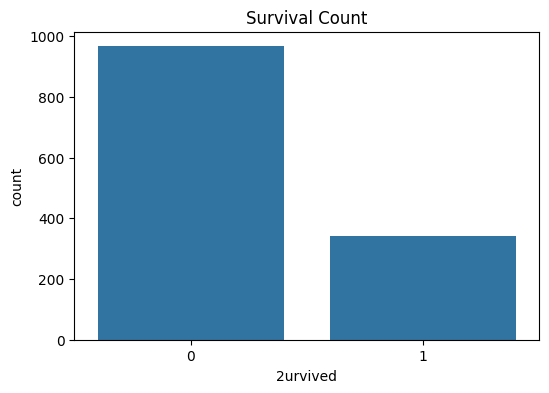

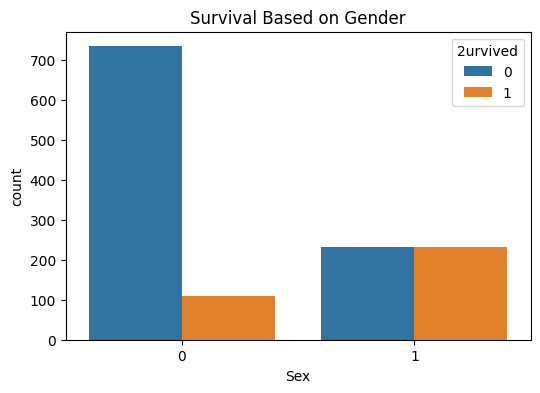

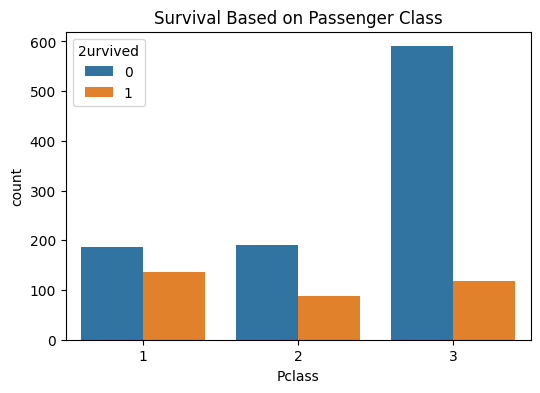

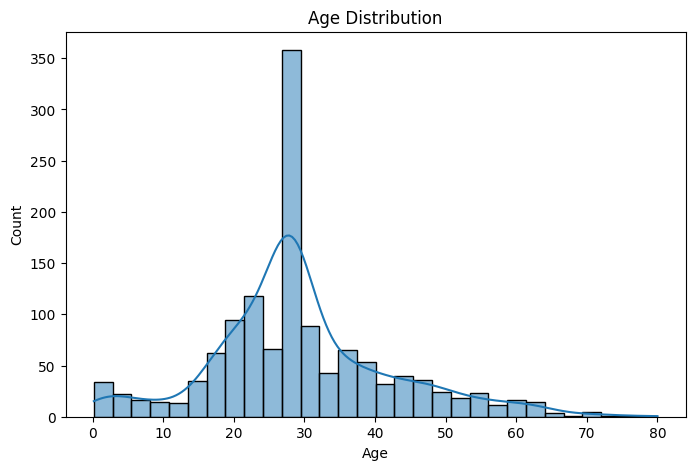

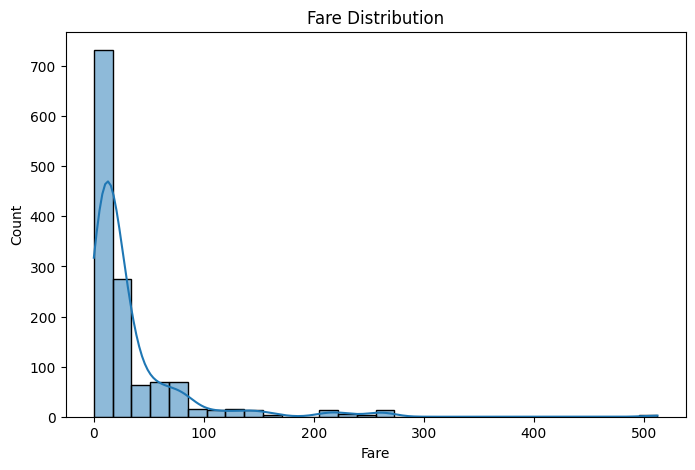

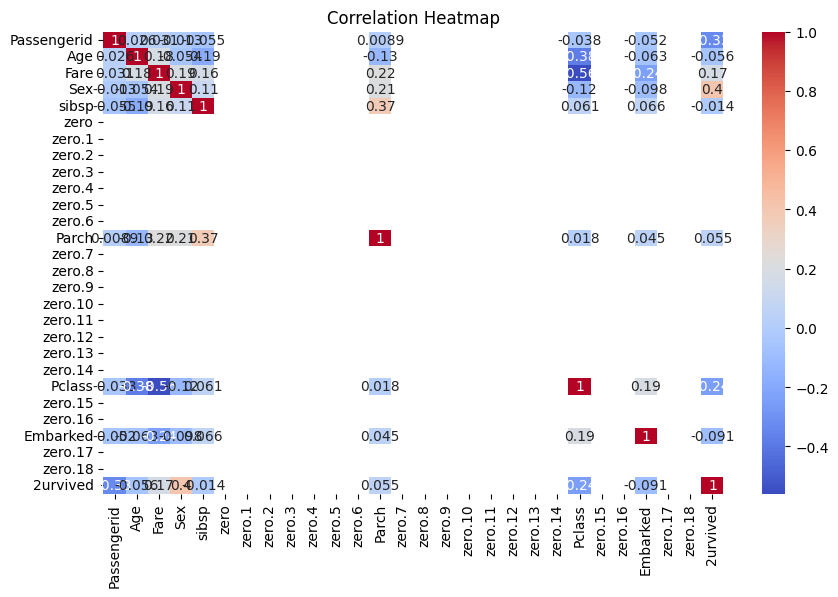


KEY OBSERVATIONS:
1. Female passengers had higher survival rate.
2. First class passengers survived more.
3. Most passengers were between age 20-40.
4. Fare and passenger class affected survival.
5. Missing values were cleaned successfully.

CONCLUSION:
EDA on Titanic dataset helped identify patterns
between survival, gender, age, class, and fare.


In [ ]:
# TITANIC DATASET - DATA CLEANING AND EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# DOWNLOAD TITANIC DATASET FROM KAGGLE

path = kagglehub.dataset_download("heptapod/titanic")

print("Dataset downloaded to:", path)

files = os.listdir(path)
print("Files in dataset folder:", files)

csv_path = os.path.join(path, "train_and_test2.csv")

df = pd.read_csv(csv_path)

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

print("\nMISSING VALUES")
print(df.isnull().sum())

# DATA CLEANING
# Fill missing Age values
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values
if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column if exists
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# EDA - EXPLORATORY DATA ANALYSIS
# Survival Count
plt.figure(figsize=(6,4))
sns.countplot(x='2urvived', data=df)
plt.title("Survival Count")
plt.show()

# Survival Based on Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='2urvived', data=df)
plt.title("Survival Based on Gender")
plt.show()

# Survival Based on Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='2urvived', data=df)
plt.title("Survival Based on Passenger Class")
plt.show()

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Fare Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

# Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# OBSERVATIONS

print("\nKEY OBSERVATIONS:")
print("1. Female passengers had higher survival rate.")
print("2. First class passengers survived more.")
print("3. Most passengers were between age 20-40.")
print("4. Fare and passenger class affected survival.")
print("5. Missing values were cleaned successfully.")

# CONCLUSION

print("\nCONCLUSION:")
print("EDA on Titanic dataset helped identify patterns")
print("between survival, gender, age, class, and fare.")